# First-Principles Derivation — 6-DOF Rocket-Landing Dynamics

This notebook derives the equations of motion used by ZetaBench's reference environment,
from Newton's and Euler's laws to the exact expressions implemented in
[`dynamics/equations_of_motion.py`](../dynamics/equations_of_motion.py).

**What this notebook is.** The reference derivation for the *moderate-fidelity* tier: every
term in the implemented model is derived here, then checked numerically against the code that
the environment actually runs. It doubles as an executable audit — if `dynamics/` and this
derivation ever disagree, a cell below fails.

**What this notebook is not.** It is not a high-fidelity aerodynamic model. Density is
constant, drag is a single coefficient, the inertia tensor is fixed, and there is no engine
spool-up or RCS. Those simplifications are stated where they are made and collected in §9.

**How to run**

```bash
pip install -r requirements.lock          # runtime deps: numpy, matplotlib, omegaconf
pip install jupyterlab                    # notebook tooling is not in the lockfile
jupyter lab notebooks/physics_derivation.ipynb
```

Nothing here needs torch or a trained checkpoint — the notebook exercises `dynamics/` only.
Every cell reads its parameters from `configs/env.yaml`, so the numbers below are the numbers
the simulator uses; nothing is hardcoded here. Cells assert their results, so a green run *is*
the check.

| § | Topic | Implemented in |
|---|---|---|
| 1 | Frames, state vector, action vector | `dynamics/types.py` |
| 2 | Attitude: quaternion → DCM, and quaternion kinematics | `quat_rotate_body_to_inertial`, `quat_kinematics_dot` |
| 3 | Translational dynamics: thrust, gravity, drag | `compute_gravity_inertial`, `compute_drag_inertial` |
| 4 | Thrust-vector (gimbal) model | `compute_thrust_force_body` |
| 5 | Rotational dynamics: gimbal torque + Euler's equations | `compute_gimbal_torque_body`, `compute_angular_acceleration` |
| 6 | Mass depletion | `state_derivative` |
| 7 | Numerical integration (RK4) and its error | `rk4_step`, `ModerateFidelityDynamics.step` |
| 8 | Parameter grounding | `docs/parameter_sources.md` |
| 9 | Validity envelope, limitations, open discrepancies | — |

In [1]:
"""Setup: import the project's dynamics and load the real vehicle parameters."""
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from omegaconf import OmegaConf

from dynamics.equations_of_motion import (
    G0_TSIOLKOVSKY,
    G_EARTH,
    RHO_AIR_SEA_LEVEL,
    compute_angular_acceleration,
    compute_drag_inertial,
    compute_gimbal_torque_body,
    compute_gravity_inertial,
    compute_thrust_force_body,
    quat_kinematics_dot,
    quat_rotate_body_to_inertial,
    state_derivative,
)
from dynamics.moderate_fidelity import ModerateFidelityDynamics, ModerateFidelityParams
from dynamics.types import (
    ACTION_DIM,
    IDENTITY_QUAT,
    STATE_DIM,
    UPRIGHT_QUAT,
    make_state,
)

np.set_printoptions(precision=6, suppress=True)

# Parameters come from configs/env.yaml — the same file the environment reads.
cfg = OmegaConf.load(REPO_ROOT / "configs" / "env.yaml")
d = cfg.env.dynamics
PARAMS = ModerateFidelityParams(
    dry_mass_kg=float(d.dry_mass_kg),
    initial_fuel_kg=float(d.initial_fuel_kg),
    max_thrust_N=float(d.max_thrust_N),
    isp_s=float(d.isp_s),
    drag_coefficient=float(d.drag_coefficient),
    reference_area_m2=float(d.reference_area_m2),
    inertia_xx=float(d.inertia_xx),
    inertia_yy=float(d.inertia_yy),
    inertia_zz=float(d.inertia_zz),
    gimbal_max_rad=float(d.gimbal_max_rad),
    throttle_min=float(d.throttle_min),
    throttle_max=float(d.throttle_max),
    physics_substeps=int(cfg.env.episode.physics_substeps),
    engine_lever_arm_m=float(d.engine_lever_arm_m),
)
DYN = ModerateFidelityDynamics(PARAMS)
DT_CONTROL = 1.0 / float(cfg.env.episode.control_hz)
M_WET = PARAMS.dry_mass_kg + PARAMS.initial_fuel_kg

print(f"control tick   dt = {DT_CONTROL*1000:.0f} ms ({cfg.env.episode.control_hz} Hz)")
print(f"physics substep   = {DT_CONTROL/PARAMS.physics_substeps*1000:.1f} ms "
      f"({PARAMS.physics_substeps} RK4 substeps -> "
      f"{cfg.env.episode.control_hz * PARAMS.physics_substeps} Hz)")
print(f"wet mass          = {M_WET:,.0f} kg   (dry {PARAMS.dry_mass_kg:,.0f} + "
      f"fuel {PARAMS.initial_fuel_kg:,.0f})")
print(f"max thrust        = {PARAMS.max_thrust_N:,.0f} N   "
      f"(T/W = {PARAMS.max_thrust_N/(M_WET*G_EARTH):.2f} at wet mass)")

control tick   dt = 20 ms (50 Hz)
physics substep   = 5.0 ms (4 RK4 substeps -> 200 Hz)
wet mass          = 30,000 kg   (dry 25,000 + fuel 5,000)
max thrust        = 845,000 N   (T/W = 2.87 at wet mass)


---

## 1. Frames, state, and action

### 1.1 Reference frames

Two right-handed frames, both standard in flight dynamics:

| Frame | Axes | Used for |
|---|---|---|
| **Inertial — NED** | $X$ = North, $Y$ = East, $Z$ = **Down** | position, velocity, gravity, wind |
| **Body — FRD** | $x_b$ = Forward (nose), $y_b$ = Right, $z_b$ = Down (belly) | thrust, torque, angular rate, inertia |

The pad sits at the NED origin, so **altitude is $-z$**: the vehicle descends as $z \to 0^-$,
and touchdown is $z \ge 0$. Gravity is $+\hat{z}$, i.e. $\mathbf{g} = (0,0,+g)$ — no minus sign,
because $Z$ already points down. NED is chosen over ENU precisely so that a landing problem has
gravity along a positive axis and altitude as a simple sign flip.

### 1.2 State vector ($n = 14$)

$$
\mathbf{s} = \begin{bmatrix}
\mathbf{p}_{\text{NED}} & \mathbf{v}_{\text{NED}} & \mathbf{q} & \boldsymbol{\omega}_b & m_f
\end{bmatrix}^\top
\in \mathbb{R}^{14}
$$

| Slice | Symbol | Quantity | Units |
|---|---|---|---|
| `[0:3]` | $\mathbf{p}$ | position, NED | m |
| `[3:6]` | $\mathbf{v}$ | velocity, NED | m/s |
| `[6:10]` | $\mathbf{q} = (w,x,y,z)$ | attitude, body→inertial, unit norm | — |
| `[10:13]` | $\boldsymbol{\omega}_b = (p,q,r)$ | angular rate, **body frame** | rad/s |
| `[13]` | $m_f$ | fuel mass | kg |

Attitude is a **quaternion, not Euler angles**, because the natural landing attitude
(nose straight up) is exactly the ZYX gimbal-lock singularity at $\theta = +\pi/2$. Euler angles
are produced only for the observation vector, where the singularity is harmless.

Angular rate is stored in the **body** frame because that is the frame in which Euler's equations
are diagonal (§5) and in which a rate gyro would measure it.

### 1.3 Action vector ($m = 3$)

$$
\mathbf{u} = \begin{bmatrix} \tau & \delta_p & \delta_y \end{bmatrix}^\top,
\qquad \tau \in [0,1], \quad \delta_p, \delta_y \in [-1,1]
$$

throttle plus two normalised gimbal deflections. The bound on $\tau$ is **asymmetric on purpose**:
a rocket engine cannot produce negative thrust, so it is a constraint on the action space rather
than something a controller must be penalised into respecting.

### 1.4 The nose-up attitude is not the identity

Body $+x_b$ (nose) aligned with inertial $-Z$ (up) is a $+90^\circ$ rotation about $Y$:

$$
\mathbf{q}_{\text{up}} = \left(\cos 45^\circ,\; 0,\; \sin 45^\circ,\; 0\right)
= \left(\tfrac{\sqrt{2}}{2},\, 0,\, \tfrac{\sqrt{2}}{2},\, 0\right)
$$

In [2]:
"""Check §1.4: the stored UPRIGHT_QUAT really does point the nose up."""
nose_body = np.array([1.0, 0.0, 0.0])          # +x_b, the thrust axis
nose_inertial = quat_rotate_body_to_inertial(UPRIGHT_QUAT, nose_body)

print("STATE_DIM, ACTION_DIM      :", STATE_DIM, ACTION_DIM)
print("q_up                       :", UPRIGHT_QUAT)
print("cos(45 deg), sin(45 deg)   :", np.cos(np.pi/4), np.sin(np.pi/4))
print("R(q_up) @ nose_body        :", nose_inertial, " <- (0,0,-1) = straight up in NED")
assert np.allclose(nose_inertial, [0.0, 0.0, -1.0], atol=1e-12)

# ...and the identity quaternion leaves the rocket lying on its side, nose North.
print("R(q_identity) @ nose_body  :", quat_rotate_body_to_inertial(IDENTITY_QUAT, nose_body),
      " <- horizontal, pointing North")

STATE_DIM, ACTION_DIM      : 14 3
q_up                       : [0.707107 0.       0.707107 0.      ]
cos(45 deg), sin(45 deg)   : 0.7071067811865476 0.7071067811865475
R(q_up) @ nose_body        : [-0.  0. -1.]  <- (0,0,-1) = straight up in NED
R(q_identity) @ nose_body  : [1. 0. 0.]  <- horizontal, pointing North


---

## 2. Attitude: rotation and kinematics

### 2.1 Quaternion → rotation matrix

For a unit quaternion $\mathbf{q} = (w,x,y,z)$ in the Hamilton convention, a body vector is
carried to the inertial frame by $\mathbf{v}_I = \mathbf{q} \otimes \mathbf{v}_b \otimes \mathbf{q}^{-1}$.
Expanding that product and collecting terms gives the direction-cosine matrix used in the code:

$$
R(\mathbf{q}) =
\begin{bmatrix}
1-2(y^2+z^2) & 2(xy-wz)     & 2(xz+wy) \\
2(xy+wz)     & 1-2(x^2+z^2) & 2(yz-wx) \\
2(xz-wy)     & 2(yz+wx)     & 1-2(x^2+y^2)
\end{bmatrix}
$$

Two properties are worth checking rather than assuming, because a sign slip here silently
corrupts every force in the model: $R^\top R = I$ (orthonormal) and $\det R = +1$ (a rotation,
not a reflection).

### 2.2 Quaternion kinematics

Attitude propagates by

$$
\dot{\mathbf{q}} = \tfrac{1}{2}\, \mathbf{q} \otimes \tilde{\boldsymbol{\omega}},
\qquad \tilde{\boldsymbol{\omega}} = (0,\, p,\, q,\, r)
$$

Writing out the Hamilton product with $\boldsymbol{\omega}_b = (p, q, r)$:

$$
\dot{\mathbf{q}} = \frac{1}{2}
\begin{bmatrix}
-xp - yq - zr \\
\;\;wp + yr - zq \\
\;\;wq - xr + zp \\
\;\;wr + xq - yp
\end{bmatrix}
$$

This is a *linear* ODE in $\mathbf{q}$ with no trigonometric functions and no singularity — the
practical reason to carry a quaternion. Its one cost is that finite-step integration drifts off
the unit sphere at $\mathcal{O}(\Delta t^2)$, which §7 handles by renormalising after every substep.

Reference: Wertz, *Spacecraft Attitude Determination and Control*, §16.1.

In [3]:
"""Check §2.1: R is a proper rotation, for an arbitrary attitude."""
rng = np.random.default_rng(0)
q_rand = rng.normal(size=4)
q_rand /= np.linalg.norm(q_rand)

# Rebuild R column-by-column from the code's rotation function.
R = np.column_stack([quat_rotate_body_to_inertial(q_rand, e) for e in np.eye(3)])
print("q            :", q_rand)
print("max |RᵀR - I| :", np.abs(R.T @ R - np.eye(3)).max())
print("det(R)        :", np.linalg.det(R))
assert np.abs(R.T @ R - np.eye(3)).max() < 1e-12
assert abs(np.linalg.det(R) - 1.0) < 1e-12

q            : [ 0.186517 -0.195973  0.950047  0.155616]
max |RᵀR - I| : 1.1102230246251565e-16
det(R)        : 0.9999999999999999


In [4]:
"""Check §2.2: quat_kinematics_dot matches a finite difference of exact quaternion rotation."""
def quat_mul(a, b):
    """Hamilton product a ⊗ b."""
    w0, x0, y0, z0 = a
    w1, x1, y1, z1 = b
    return np.array([
        w0*w1 - x0*x1 - y0*y1 - z0*z1,
        w0*x1 + x0*w1 + y0*z1 - z0*y1,
        w0*y1 - x0*z1 + y0*w1 + z0*x1,
        w0*z1 + x0*y1 - y0*x1 + z0*w1,
    ])

def propagate_exact(q, omega, t):
    """Exact attitude after rotating at constant body rate `omega` for time `t`."""
    angle = np.linalg.norm(omega) * t
    axis = omega / np.linalg.norm(omega)
    dq = np.concatenate([[np.cos(angle/2)], np.sin(angle/2) * axis])
    return quat_mul(q, dq)

q0 = np.array([0.9, 0.1, -0.3, 0.2]); q0 /= np.linalg.norm(q0)
omega = np.array([0.3, -0.5, 0.7])          # rad/s, body frame
h = 1e-7

finite_difference = (propagate_exact(q0, omega, h) - q0) / h
analytic = quat_kinematics_dot(q0, omega)

print("finite difference :", finite_difference)
print("quat_kinematics_dot:", analytic)
print("max abs error      :", np.abs(finite_difference - analytic).max())
assert np.abs(finite_difference - analytic).max() < 1e-6

finite difference : [-0.164157  0.082078 -0.235975  0.343703]
quat_kinematics_dot: [-0.164157  0.082078 -0.235975  0.343703]
max abs error      : 8.69026112182425e-09


---

## 3. Translational dynamics

Newton's second law for a variable-mass vehicle, written in the inertial frame. Total mass is
$m(t) = m_{\text{dry}} + m_f(t)$, and the propellant leaves at the thrust exhaust, whose momentum
flux is already accounted for inside the thrust term. So:

$$
\dot{\mathbf{p}} = \mathbf{v},
\qquad
\dot{\mathbf{v}} = \frac{1}{m(t)}\Big(
\underbrace{R(\mathbf{q})\,\mathbf{F}^b_{\text{thrust}}}_{\text{§4}}
+ \underbrace{\mathbf{F}_{\text{grav}}}_{\text{3.1}}
+ \underbrace{\mathbf{F}_{\text{drag}}}_{\text{3.2}}
\Big)
$$

Thrust is generated in the body frame and rotated out; gravity and drag are natural in the
inertial frame. That split is why $R(\mathbf{q})$ appears exactly once in the translational
equation.

### 3.1 Gravity

$$
\mathbf{F}_{\text{grav}} = m(t)\,\mathbf{g}, \qquad \mathbf{g} = (0, 0, +g), \quad g = 9.81\ \text{m/s}^2
$$

Constant $g$: over a drop height under 600 m the variation of $g$ with altitude is below 0.02%,
far under every other modelling error here.

### 3.2 Aerodynamic drag

Drag acts on the velocity **relative to the air mass**, not on inertial velocity. With a steady
wind $\mathbf{v}_w$ (NED),

$$
\mathbf{v}_{\text{air}} = \mathbf{v} - \mathbf{v}_w,
\qquad
\mathbf{F}_{\text{drag}} = -\tfrac{1}{2}\,\rho\, C_d\, A_{\text{ref}}\,
\lVert \mathbf{v}_{\text{air}} \rVert\, \mathbf{v}_{\text{air}}
$$

The form $\lVert\mathbf{v}\rVert\,\mathbf{v}$ (rather than $\lVert\mathbf{v}\rVert^2$) carries both
the quadratic magnitude and the direction, and stays well defined as $\mathbf{v}\to 0$ — the code
returns zero below an airspeed of $10^{-9}$ m/s to avoid normalising a null vector.

This is also **the reason wind is specified in m/s** in the robustness grid rather than as a force:
it is a property of the air mass, and it enters physics only through this relative-airspeed term.
A vehicle drifting with the wind feels no wind force at all, which is the physically honest
behaviour and is what makes the disturbance magnitudes comparable across controllers.

Simplifications, all deliberate at this tier: $\rho$ is the ISA sea-level constant (no $\rho(h)$),
$C_d$ is a single scalar (no Mach or angle-of-attack dependence), and there is no lift or
side-force — the vehicle is treated as an aerodynamically axisymmetric bluff body.

In [5]:
"""Check §3: free fall, hover balance, quadratic drag, and the wind ⇄ airspeed equivalence."""
vacuum = ModerateFidelityDynamics(replace(PARAMS, drag_coefficient=0.0))

# (a) Vacuum free fall for 2 s must reproduce the closed form z = ½gt², v = gt.
s = make_state(np.zeros(3), np.zeros(3), IDENTITY_QUAT, np.zeros(3), PARAMS.initial_fuel_kg)
for _ in range(int(2.0 / DT_CONTROL)):
    s = vacuum.step(s, np.zeros(3), DT_CONTROL)
print(f"(a) free fall 2 s : z = {s[2]:.6f} m (exact {0.5*G_EARTH*4:.6f}), "
      f"v_z = {s[5]:.6f} m/s (exact {G_EARTH*2:.6f})")
assert abs(s[2] - 0.5*G_EARTH*4) < 1e-3 and abs(s[5] - G_EARTH*2) < 1e-3

# (b) Hover: the throttle that cancels weight should give zero vertical acceleration.
throttle_hover = M_WET * G_EARTH / PARAMS.max_thrust_N
s_hover = make_state(np.zeros(3), np.zeros(3), UPRIGHT_QUAT, np.zeros(3), PARAMS.initial_fuel_kg)
accel = state_derivative(s_hover, np.array([throttle_hover, 0.0, 0.0]),
                         replace(PARAMS, drag_coefficient=0.0))[5]
print(f"(b) hover throttle: {throttle_hover:.4f}  (engine floor {PARAMS.throttle_min}) "
      f"-> vertical accel {accel:+.2e} m/s²")
assert PARAMS.throttle_min <= throttle_hover <= PARAMS.throttle_max, "hover is unreachable"
assert abs(accel) < 1e-9

# (c) Drag is quadratic in airspeed and matches the closed form.
drag_10 = compute_drag_inertial(np.array([0.0, 0.0, 10.0]), PARAMS)[2]
drag_20 = compute_drag_inertial(np.array([0.0, 0.0, 20.0]), PARAMS)[2]
closed_form_20 = -0.5*RHO_AIR_SEA_LEVEL*20.0**2*PARAMS.drag_coefficient*PARAMS.reference_area_m2
print(f"(c) drag @10 m/s = {drag_10:9.1f} N ; @20 m/s = {drag_20:9.1f} N ; "
      f"ratio = {drag_20/drag_10:.3f} (expect 4) ; closed form = {closed_form_20:.1f} N")
assert np.isclose(drag_20/drag_10, 4.0) and np.isclose(drag_20, closed_form_20)

# (d) Wind is a moving air mass: 10 m/s of North wind == 10 m/s of extra South airspeed.
with_wind = compute_drag_inertial(np.array([0.0, 0.0, 20.0]), PARAMS,
                                  wind_velocity_ned=np.array([10.0, 0.0, 0.0]))
equivalent = compute_drag_inertial(np.array([-10.0, 0.0, 20.0]), PARAMS)
print(f"(d) wind equivalence, max component difference: {np.abs(with_wind - equivalent).max():.1e} N")
assert np.allclose(with_wind, equivalent)

(a) free fall 2 s : z = 19.620000 m (exact 19.620000), v_z = 19.620000 m/s (exact 19.620000)
(b) hover throttle: 0.3483  (engine floor 0.25) -> vertical accel -1.94e-15 m/s²
(c) drag @10 m/s =    -482.3 N ; @20 m/s =   -1929.4 N ; ratio = 4.000 (expect 4) ; closed form = -1929.4 N
(d) wind equivalence, max component difference: 0.0e+00 N


unpowered terminal velocity : 247 m/s (12x the fastest initial descent)
drag at 20 m/s          : 1929 N = 0.67% of weight
=> in this envelope the vehicle is thrust/gravity dominated; drag matters mainly as
   the channel through which wind disturbances act.


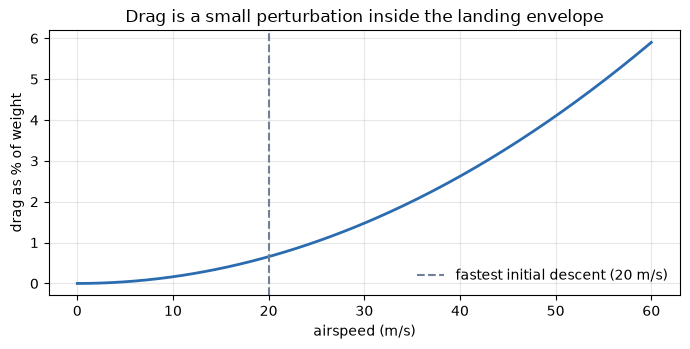

In [6]:
"""How much does drag actually matter in the landing regime?"""
weight = M_WET * G_EARTH
v_terminal = np.sqrt(2*M_WET*G_EARTH /
                     (RHO_AIR_SEA_LEVEL * PARAMS.drag_coefficient * PARAMS.reference_area_m2))

speeds = np.linspace(0.0, 60.0, 200)
drag_fraction = np.array([
    abs(compute_drag_inertial(np.array([0.0, 0.0, v]), PARAMS)[2]) / weight for v in speeds
]) * 100.0

descent_max = float(cfg.env.init_conditions.descent_velocity_max_mps)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(speeds, drag_fraction, lw=2, color="#2b6cb0")
ax.axvline(descent_max, ls="--", c="#718096",
           label=f"fastest initial descent ({descent_max:.0f} m/s)")
ax.set_xlabel("airspeed (m/s)"); ax.set_ylabel("drag as % of weight")
ax.set_title("Drag is a small perturbation inside the landing envelope")
ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.tight_layout()

print(f"unpowered terminal velocity : {v_terminal:.0f} m/s "
      f"({v_terminal/descent_max:.0f}x the fastest initial descent)")
print(f"drag at {descent_max:.0f} m/s          : "
      f"{abs(compute_drag_inertial(np.array([0., 0., descent_max]), PARAMS)[2]):.0f} N "
      f"= {drag_fraction[np.searchsorted(speeds, descent_max)]:.2f}% of weight")
print("=> in this envelope the vehicle is thrust/gravity dominated; drag matters mainly as")
print("   the channel through which wind disturbances act.")

---

## 4. Thrust-vector model (gimbal abstraction)

A single engine is mounted on a two-axis gimbal below the centre of mass. Undeflected it fires
along $-x_b$, pushing the vehicle along $+x_b$ — nose-forward, which for the landing attitude of
§1.4 is straight up.

### 4.1 Magnitude

$$
T = \operatorname{clamp}(\tau)\cdot T_{\max},
\qquad
\operatorname{clamp}(\tau) =
\begin{cases}
0 & m_f \le 0 \ \ \text{or} \ \ \tau \le 0 \\[2pt]
\min\!\big(\max(\tau, \tau_{\min}),\, \tau_{\max}\big) & \tau > 0
\end{cases}
$$

A liquid engine cannot sustain combustion below its minimum throttle, so the model gives the
engine an explicit **off** state at $\tau \le 0$ and otherwise holds any positive command at the
floor $\tau_{\min}$ — "minimum sustainable thrust" semantics.

The consequence is a genuine **discontinuity at $\tau \to 0^+$**: thrust jumps from $0$ to
$\tau_{\min} T_{\max} \approx 211$ kN with no continuous path between them. That is a property of
the real hardware, and it is one of the things that makes this a harder control problem than a
smooth thrust model — a controller must commit to shutting the engine down rather than easing
into it.

(The docstring of `clamp_throttle` describes the opposite convention — below-floor commands
mapping to zero. The implementation, and therefore the plant, is the clamp-up rule above; the
cell below demonstrates which one is live. Recorded in §9.4.)

### 4.2 Direction

With normalised commands $\delta_p, \delta_y \in [-1,1]$ scaled to physical deflections
$\varepsilon_p = \delta_p\,\varepsilon_{\max}$ and $\varepsilon_y = \delta_y\,\varepsilon_{\max}$,
two successive small rotations of the thrust axis give

$$
\hat{\mathbf{F}}^b_{\text{thrust}} =
\begin{bmatrix}
\cos\varepsilon_p \cos\varepsilon_y \\
\cos\varepsilon_p \sin\varepsilon_y \\
-\sin\varepsilon_p
\end{bmatrix},
\qquad
\mathbf{F}^b_{\text{thrust}} = T\, \hat{\mathbf{F}}^b_{\text{thrust}}
$$

which is a unit vector for any $(\varepsilon_p, \varepsilon_y)$ — deflecting the gimbal **redirects**
thrust, it does not create or destroy it. Sign convention: positive $\varepsilon_p$ tilts thrust
toward $-z_b$, positive $\varepsilon_y$ toward $+y_b$.

### 4.3 The cosine loss, and how little authority ±5° buys

The axial component is $T\cos\varepsilon_p\cos\varepsilon_y$, so at full deflection the vehicle
loses $1 - \cos\varepsilon_{\max}$ of its lifting thrust while gaining $T\sin\varepsilon_{\max}$ of
side force. With $\varepsilon_{\max} = 5^\circ$ that trade is very lopsided, and it is worth
knowing the resulting lateral acceleration before asking any controller to steer with it.

In [7]:
"""Check §4 and quantify the control authority the gimbal actually provides."""
# (a) Direction is a unit vector, so |F| is exactly T regardless of deflection.
for label, action in [("no gimbal   ", np.array([1.0, 0.0, 0.0])),
                      ("full pitch  ", np.array([1.0, 1.0, 0.0])),
                      ("full diagonal", np.array([1.0, 1.0, 1.0]))]:
    F = compute_thrust_force_body(action, PARAMS, fuel_mass_kg=1000.0)
    print(f"(a) {label}: F_body = {F.round(1)}  |F| = {np.linalg.norm(F):,.1f} N")
    assert np.isclose(np.linalg.norm(F), PARAMS.max_thrust_N)

# (b) Throttle saturation and the fuel-empty / engine-off cutoffs.
def thrust_of(tau, fuel=1000.0):
    return float(np.linalg.norm(compute_thrust_force_body(np.array([tau, 0.0, 0.0]), PARAMS, fuel)))

print("(b) throttle map:")
for tau in [0.0, 0.01, 0.10, PARAMS.throttle_min, 0.50, 1.00, 1.50]:
    note = ("engine off" if thrust_of(tau) == 0.0 else
            "raised to floor" if tau < PARAMS.throttle_min else
            "saturated" if tau > PARAMS.throttle_max else "as commanded")
    print(f"    tau = {tau:>4.2f} -> {thrust_of(tau):>9,.0f} N   ({note})")
print(f"    tau = 1.00 with an empty tank -> {thrust_of(1.0, fuel=0.0):,.0f} N")
assert thrust_of(1.50) == PARAMS.max_thrust_N and thrust_of(1.0, fuel=0.0) == 0.0

# The discontinuity a controller has to deal with: no thrust exists between 0 and the floor.
print(f"\n    thrust jump across tau=0+: 0 N -> {thrust_of(1e-9):,.0f} N "
      f"({thrust_of(1e-9)/(M_WET*G_EARTH):.2f}x weight)")
assert thrust_of(0.0) == 0.0 and thrust_of(1e-9) == PARAMS.throttle_min * PARAMS.max_thrust_N

# (c) The cosine-loss / side-force trade at full deflection.
eps = PARAMS.gimbal_max_rad
print(f"\n(c) gimbal range          : ±{np.degrees(eps):.1f}°")
print(f"    axial thrust retained : {np.cos(eps)*100:.2f}%  (cosine loss {100*(1-np.cos(eps)):.2f}%)")
print(f"    side force at full    : {PARAMS.max_thrust_N*np.sin(eps):,.0f} N")
print(f"    lateral acceleration  : {PARAMS.max_thrust_N*np.sin(eps)/M_WET:.2f} m/s² "
      f"({PARAMS.max_thrust_N*np.sin(eps)/M_WET/G_EARTH:.2f} g)")
print("    => translation is not steered directly; it is steered by tilting the vehicle,")
print("       which makes lateral guidance an attitude problem (see §5).")

(a) no gimbal   : F_body = [845000.      0.     -0.]  |F| = 845,000.0 N
(a) full pitch  : F_body = [841782.       0.  -73674.8]  |F| = 845,000.0 N
(a) full diagonal: F_body = [838576.4  73394.3 -73674.8]  |F| = 845,000.0 N
(b) throttle map:
    tau = 0.00 ->         0 N   (engine off)
    tau = 0.01 ->   211,250 N   (raised to floor)
    tau = 0.10 ->   211,250 N   (raised to floor)
    tau = 0.25 ->   211,250 N   (as commanded)
    tau = 0.50 ->   422,500 N   (as commanded)
    tau = 1.00 ->   845,000 N   (as commanded)
    tau = 1.50 ->   845,000 N   (saturated)
    tau = 1.00 with an empty tank -> 0 N

    thrust jump across tau=0+: 0 N -> 211,250 N (0.72x weight)

(c) gimbal range          : ±5.0°
    axial thrust retained : 99.62%  (cosine loss 0.38%)
    side force at full    : 73,675 N
    lateral acceleration  : 2.46 m/s² (0.25 g)
    => translation is not steered directly; it is steered by tilting the vehicle,
       which makes lateral guidance an attitude problem (see §5).


---

## 5. Rotational dynamics

### 5.1 Gimbal torque

The engine acts at $\mathbf{r} = (-L, 0, 0)$ in the body frame, a distance
$L = $ `engine_lever_arm_m` **behind** the centre of mass. The torque is $\boldsymbol{\tau} =
\mathbf{r} \times \mathbf{F}^b$:

$$
\boldsymbol{\tau} = \begin{bmatrix} -L \\ 0 \\ 0 \end{bmatrix} \times
\begin{bmatrix} F_x \\ F_y \\ F_z \end{bmatrix}
= \begin{bmatrix}
0\cdot F_z - 0 \cdot F_y \\
0\cdot F_x - (-L) F_z \\
(-L) F_y - 0\cdot F_x
\end{bmatrix}
= \begin{bmatrix} 0 \\ +L F_z \\ -L F_y \end{bmatrix}
$$

### 5.2 A structural consequence: no roll authority

$\tau_x \equiv 0$ for **every** action. This is not an approximation — it follows from the
cross product: a force applied along the line through the centre of mass and the gimbal pivot
has no moment arm about that same axis. A single gimballed engine cannot roll the vehicle.

Real Falcon-9-class stages use cold-gas RCS thrusters for roll, which this tier does not model.
The consequence is carried honestly downstream: roll is uncontrollable, so the success criterion
is stated in terms of tilt-from-vertical and angular-rate magnitude rather than a roll target,
and it is listed under README §Limitations. It is a genuine property of the modelled vehicle,
not a bug to be patched at the reward level.

### 5.3 Euler's equations

In the body frame, with the principal-axes assumption $I = \operatorname{diag}(I_{xx},I_{yy},I_{zz})$:

$$
I\,\dot{\boldsymbol{\omega}} + \boldsymbol{\omega} \times (I\,\boldsymbol{\omega}) = \boldsymbol{\tau}
$$

Component-wise,

$$
\dot{p} = \frac{\tau_x - (I_{zz}-I_{yy})\,q\,r}{I_{xx}},\qquad
\dot{q} = \frac{\tau_y - (I_{xx}-I_{zz})\,r\,p}{I_{yy}},\qquad
\dot{r} = \frac{\tau_z - (I_{yy}-I_{xx})\,p\,q}{I_{zz}}
$$

The $\boldsymbol{\omega} \times (I\boldsymbol{\omega})$ term is gyroscopic coupling, and it is
real physics rather than a frame artefact: it is what makes a tumbling asymmetric body exchange
angular velocity between axes while conserving angular **momentum** in the inertial frame. That
conservation is the sharpest available test of both the Euler implementation and the attitude
integrator, so §5.4 checks it directly.

Reference: Greenwood, *Advanced Dynamics*, §8.3.

In [8]:
"""Check §5.1–5.2: the torque formula, and that roll torque is identically zero."""
F = compute_thrust_force_body(np.array([1.0, 1.0, 0.0]), PARAMS, fuel_mass_kg=1000.0)
tau = compute_gimbal_torque_body(F, PARAMS.engine_lever_arm_m)
tau_y_expected = -PARAMS.engine_lever_arm_m * PARAMS.max_thrust_N * np.sin(PARAMS.gimbal_max_rad)

print(f"full pitch gimbal -> tau = {tau.round(1)} N·m")
print(f"closed form tau_y = {tau_y_expected:,.1f} N·m")
assert np.isclose(tau[1], tau_y_expected)

# Roll torque vanishes for every reachable action, not just this one.
rng = np.random.default_rng(0)
worst_roll = max(
    abs(compute_gimbal_torque_body(
        compute_thrust_force_body(
            np.array([rng.uniform(0, 1), rng.uniform(-1, 1), rng.uniform(-1, 1)]),
            PARAMS, 1000.0),
        PARAMS.engine_lever_arm_m)[0])
    for _ in range(10_000)
)
print(f"max |tau_x| over 10,000 random actions: {worst_roll:.1e} N·m  <- structurally zero")
assert worst_roll == 0.0

# Resulting angular acceleration, i.e. how fast the vehicle can actually rotate.
print(f"\npitch angular acceleration at full gimbal: {abs(tau[1])/PARAMS.inertia_yy:.3f} rad/s² "
      f"({np.degrees(abs(tau[1])/PARAMS.inertia_yy):.1f}°/s²)")

full pitch gimbal -> tau = [       0.  -1105122.5       -0. ] N·m
closed form tau_y = -1,105,122.5 N·m


max |tau_x| over 10,000 random actions: 0.0e+00 N·m  <- structurally zero

pitch angular acceleration at full gimbal: 0.442 rad/s² (25.3°/s²)


body rates start : [0.3 0.5 0.7] rad/s
body rates end   : [0.4643 0.3527 0.7   ] rad/s   <- redistributed by coupling
‖H‖ relative drift over 10 s : 2.12e-14
H  vector relative error     : 1.13e-12
‖q‖ after 500 steps          : 1.000000000000000


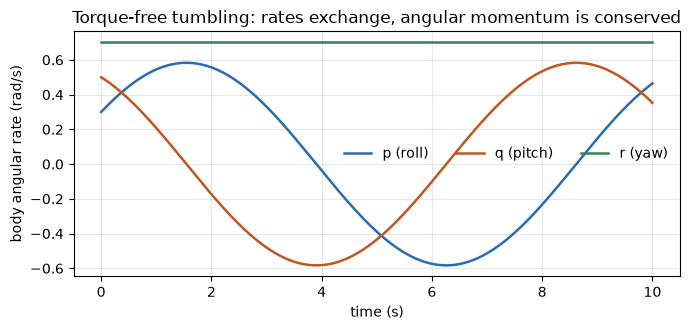

In [9]:
"""Check §5.3–5.4: torque-free tumbling must conserve inertial angular momentum."""
I_diag = np.array([PARAMS.inertia_xx, PARAMS.inertia_yy, PARAMS.inertia_zz])
vacuum = ModerateFidelityDynamics(replace(PARAMS, drag_coefficient=0.0))

s = make_state(np.zeros(3), np.zeros(3), IDENTITY_QUAT,
               np.array([0.3, 0.5, 0.7]), PARAMS.initial_fuel_kg)

def angular_momentum_inertial(state):
    """H_I = R(q) · (I ω_b) — conserved when no external torque acts."""
    return quat_rotate_body_to_inertial(state[6:10], I_diag * state[10:13])

H0 = angular_momentum_inertial(s)
omega_history, time_history = [s[10:13].copy()], [0.0]
for k in range(500):                     # 10 s of free tumbling, zero thrust
    s = vacuum.step(s, np.zeros(3), DT_CONTROL)
    omega_history.append(s[10:13].copy())
    time_history.append((k + 1) * DT_CONTROL)
H1 = angular_momentum_inertial(s)

omega_history = np.array(omega_history)
print(f"body rates start : {omega_history[0].round(4)} rad/s")
print(f"body rates end   : {omega_history[-1].round(4)} rad/s   <- redistributed by coupling")
print(f"‖H‖ relative drift over 10 s : {abs(np.linalg.norm(H1)-np.linalg.norm(H0))/np.linalg.norm(H0):.2e}")
print(f"H  vector relative error     : {np.linalg.norm(H1-H0)/np.linalg.norm(H0):.2e}")
print(f"‖q‖ after 500 steps          : {np.linalg.norm(s[6:10]):.15f}")
assert np.linalg.norm(H1 - H0) / np.linalg.norm(H0) < 1e-9

fig, ax = plt.subplots(figsize=(7, 3.4))
for i, (name, colour) in enumerate(zip(["p (roll)", "q (pitch)", "r (yaw)"],
                                       ["#2b6cb0", "#c05621", "#2f855a"])):
    ax.plot(time_history, omega_history[:, i], label=name, color=colour, lw=1.8)
ax.set_xlabel("time (s)"); ax.set_ylabel("body angular rate (rad/s)")
ax.set_title("Torque-free tumbling: rates exchange, angular momentum is conserved")
ax.legend(frameon=False, ncol=3); ax.grid(alpha=0.3)
fig.tight_layout()

---

## 6. Mass depletion

Propellant flow follows from the definition of specific impulse, $I_{sp} = T / (\dot{m}\, g_0)$:

$$
\dot{m}_f = -\frac{\lVert \mathbf{F}^b_{\text{thrust}} \rVert}{I_{sp}\, g_0},
\qquad g_0 = 9.80665\ \text{m/s}^2
$$

Two details that are easy to get wrong:

- $g_0$ is the **definitional** standard gravity used to define $I_{sp}$ in seconds. It is not
  the local gravitational acceleration, and the model deliberately keeps it separate from the
  $g = 9.81$ used in the weight term.
- The numerator is the thrust **magnitude**, which already includes throttle clamping, the
  fuel-empty cutoff, and the (tiny) gimbal cosine loss. Using the commanded throttle instead
  would burn propellant during an engine-off command.

This is the Tsiolkovsky relation in rate form. Integrating it at constant thrust recovers the
familiar rocket equation; here it simply couples mass into the translational dynamics, making
the plant time-varying — which is one of the properties a fixed-gain controller has to survive.

In [10]:
"""Check §6: burn rate, and what the propellant budget buys."""
vacuum = ModerateFidelityDynamics(replace(PARAMS, drag_coefficient=0.0))
s = make_state(np.zeros(3), np.zeros(3), UPRIGHT_QUAT, np.zeros(3), PARAMS.initial_fuel_kg)
for _ in range(int(0.5 / DT_CONTROL)):
    s = vacuum.step(s, np.array([1.0, 0.0, 0.0]), DT_CONTROL)

mdot_full = PARAMS.max_thrust_N / (PARAMS.isp_s * G0_TSIOLKOVSKY)
print(f"burn rate at full throttle : {mdot_full:.2f} kg/s")
print(f"fuel after 0.5 s           : {s[13]:.4f} kg  (closed form "
      f"{PARAMS.initial_fuel_kg - mdot_full*0.5:.4f})")
assert np.isclose(s[13], PARAMS.initial_fuel_kg - mdot_full*0.5, rtol=1e-6)

throttle_hover = M_WET * G_EARTH / PARAMS.max_thrust_N
mdot_hover = mdot_full * throttle_hover
episode_seconds = int(cfg.env.episode.max_steps) * DT_CONTROL
print(f"\npropellant reserve         : {PARAMS.initial_fuel_kg:,.0f} kg")
print(f"  endurance at full throttle: {PARAMS.initial_fuel_kg/mdot_full:5.1f} s")
print(f"  endurance hovering        : {PARAMS.initial_fuel_kg/mdot_hover:5.1f} s "
      f"(throttle {throttle_hover:.3f})")
print(f"  episode time limit        : {episode_seconds:5.1f} s "
      f"({cfg.env.episode.max_steps} steps @ {cfg.env.episode.control_hz} Hz)")
print("=> propellant is a live constraint: a policy that hovers indefinitely runs the tank dry")
print("   before the episode clock expires, so fuel is a real part of the control problem.")

burn rate at full throttle : 305.55 kg/s
fuel after 0.5 s           : 4847.2234 kg  (closed form 4847.2234)

propellant reserve         : 5,000 kg
  endurance at full throttle:  16.4 s
  endurance hovering        :  47.0 s (throttle 0.348)
  episode time limit        :  50.0 s (2500 steps @ 50 Hz)
=> propellant is a live constraint: a policy that hovers indefinitely runs the tank dry
   before the episode clock expires, so fuel is a real part of the control problem.


---

## 7. Numerical integration

Assembling §3–§6 gives the full derivative $\dot{\mathbf{s}} = f(\mathbf{s}, \mathbf{u})$, which is
integrated with classical fourth-order Runge–Kutta under a zero-order hold on the action:

$$
\begin{aligned}
k_1 &= f(\mathbf{s}_n,\ \mathbf{u}) &
k_2 &= f(\mathbf{s}_n + \tfrac{h}{2}k_1,\ \mathbf{u}) \\
k_3 &= f(\mathbf{s}_n + \tfrac{h}{2}k_2,\ \mathbf{u}) &
k_4 &= f(\mathbf{s}_n + h\,k_3,\ \mathbf{u}) \\[4pt]
\mathbf{s}_{n+1} &= \mathbf{s}_n + \tfrac{h}{6}\left(k_1 + 2k_2 + 2k_3 + k_4\right)
\end{aligned}
$$

with local truncation error $\mathcal{O}(h^5)$ and global error $\mathcal{O}(h^4)$.

**Substeps.** The controller runs at `control_hz`, but each control tick is integrated in
`physics_substeps` equal RK4 substeps. Control rate and integration accuracy are therefore
decoupled: the agent's decision frequency can be chosen for the learning problem while the
physics stays accurate.

**Post-step housekeeping**, applied after every substep:

1. **Renormalise $\mathbf{q}$.** The kinematics of §2.2 are exact in continuous time but drift off
   the unit sphere under finite steps; renormalisation is the standard projection back onto it.
2. **Clamp $m_f \ge 0$.** A sustained thrust command can otherwise drive the fuel state negative
   within a step.

Both are corrections to *numerics*, not to physics — worth naming explicitly, since silently
projecting a state is exactly the kind of thing that makes a simulator hard to trust.

### 7.1 Verifying the order of accuracy

The cheapest way to catch an integrator bug is to measure its convergence rate: halve $h$ and the
global error should fall by $2^4 = 16$. The cell below integrates one second of powered, tumbling,
drag-coupled flight at several step sizes against a high-resolution reference and fits the slope
on a log–log plot. Anything short of ≈4 would mean the RK4 blend, the substep loop, or the
renormalisation is wrong.

dt = 25.000 ms   ‖error‖ = 4.287e-08 m
dt = 12.500 ms   ‖error‖ = 2.679e-09 m
dt =  6.250 ms   ‖error‖ = 1.674e-10 m
dt =  3.125 ms   ‖error‖ = 1.050e-11 m

error ratio per halving: [16.   16.   15.94]  (RK4 expects ≈16)
empirical order of accuracy: 3.999   (theory: 4)


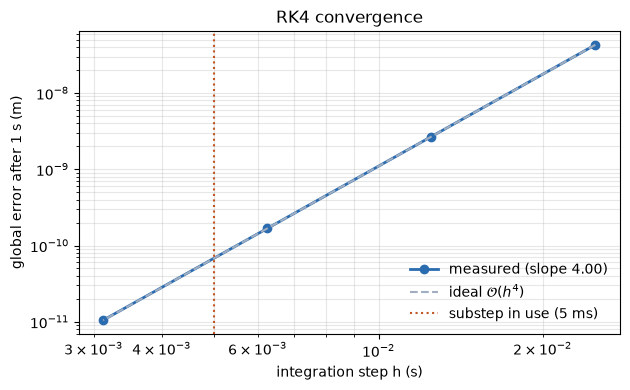

In [11]:
"""Check §7.1: measure the empirical order of accuracy of the integrator."""
# One RK4 substep per call so `dt` is exactly the integration step under test.
single = ModerateFidelityDynamics(replace(PARAMS, physics_substeps=1))

def integrate(dt, duration=1.0):
    """Powered, tumbling, drag-coupled flight — every term of f() is exercised."""
    state = make_state(np.array([0.0, 0.0, -100.0]),     # 100 m altitude
                       np.array([2.0, -1.0, 20.0]),      # descending, drifting
                       UPRIGHT_QUAT,
                       np.array([0.05, -0.10, 0.20]),    # tumbling
                       PARAMS.initial_fuel_kg)
    action = np.array([0.6, 0.3, -0.2])                  # throttle + both gimbal axes
    for _ in range(int(round(duration / dt))):
        state = single.step(state, action, dt)
    return state

reference = integrate(1.0 / 20480)
step_sizes = np.array([1/40, 1/80, 1/160, 1/320])
errors = np.array([np.linalg.norm(integrate(dt)[:6] - reference[:6]) for dt in step_sizes])

for dt, err in zip(step_sizes, errors):
    print(f"dt = {dt*1000:6.3f} ms   ‖error‖ = {err:.3e} m")
print("\nerror ratio per halving:", np.round(errors[:-1] / errors[1:], 2), " (RK4 expects ≈16)")

order = np.polyfit(np.log(step_sizes), np.log(errors), 1)[0]
print(f"empirical order of accuracy: {order:.3f}   (theory: 4)")
assert 3.8 < order < 4.2

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.loglog(step_sizes, errors, "o-", lw=2, color="#2b6cb0", label=f"measured (slope {order:.2f})")
ax.loglog(step_sizes, errors[0] * (step_sizes/step_sizes[0])**4, "--",
          color="#a0aec0", label=r"ideal $\mathcal{O}(h^4)$")
ax.axvline(DT_CONTROL/PARAMS.physics_substeps, color="#c05621", ls=":",
           label=f"substep in use ({DT_CONTROL/PARAMS.physics_substeps*1000:.0f} ms)")
ax.set_xlabel("integration step h (s)"); ax.set_ylabel("global error after 1 s (m)")
ax.set_title("RK4 convergence"); ax.legend(frameon=False); ax.grid(alpha=0.3, which="both")
fig.tight_layout()

In [12]:
"""How much accuracy do the 4 substeps actually buy at the control rate?"""
state = make_state(np.array([0.0, 0.0, -100.0]), np.array([2.0, -1.0, 20.0]),
                   UPRIGHT_QUAT, np.array([0.05, -0.10, 0.20]), PARAMS.initial_fuel_kg)
action = np.array([0.6, 0.3, -0.2])

one_step = ModerateFidelityDynamics(replace(PARAMS, physics_substeps=1)).step(state, action, DT_CONTROL)
substepped = DYN.step(state, action, DT_CONTROL)

print(f"position difference after one {DT_CONTROL*1000:.0f} ms tick, "
      f"1 substep vs {PARAMS.physics_substeps}: "
      f"{np.linalg.norm(one_step[:3] - substepped[:3]):.2e} m")
print(f"quaternion norm error, {PARAMS.physics_substeps} substeps: "
      f"{abs(np.linalg.norm(substepped[6:10]) - 1.0):.2e}")
print("=> RK4 is already accurate at 20 ms; the substeps are cheap headroom for the harder")
print("   transients (near-touchdown flare, saturated gimbal) rather than a correctness fix.")

position difference after one 20 ms tick, 1 substep vs 4: 5.50e-11 m
quaternion norm error, 4 substeps: 0.00e+00
=> RK4 is already accurate at 20 ms; the substeps are cheap headroom for the harder
   transients (near-touchdown flare, saturated gimbal) rather than a correctness fix.


---

## 8. Parameter grounding

Every value is sourced in [`docs/parameter_sources.md`](../docs/parameter_sources.md) and lives in
[`configs/env.yaml`](../configs/env.yaml). Values are Falcon-9 / Merlin-1D class, taken from public
engine and vehicle specifications.

> **Correction of an earlier claim.** Older revisions of the README stated these parameters were
> "grounded in RocketPy". That was inaccurate: RocketPy's default vehicle is a small hobbyist
> rocket, not a Falcon-class stage. The values are grounded in published SpaceX/Merlin figures
> instead, and `docs/parameter_sources.md` records the source for each one.

| Parameter | Value | Basis |
|---|---|---|
| `dry_mass_kg` | 25 000 | Falcon-9 first-stage dry mass, tanks empty |
| `initial_fuel_kg` | 5 000 | Landing-burn reserve only — this models terminal descent, not ascent |
| `max_thrust_N` | 845 000 | Merlin-1D sea-level thrust |
| `isp_s` | 282 | Merlin-1D sea-level specific impulse |
| `drag_coefficient` | 0.75 | Scalar $C_d$, slender body, subsonic |
| `reference_area_m2` | 10.5 | $\pi r^2$, $r \approx 1.83$ m |
| `inertia_xx`, `inertia_yy` | 2.5 × 10⁶ | Transverse inertia, order-of-magnitude from $\tfrac{1}{12}mL^2$ |
| `inertia_zz` | 1.2 × 10⁵ | Longitudinal-scale inertia, order-of-magnitude from $\tfrac{1}{2}mr^2$ — **see §9.2** |
| `engine_lever_arm_m` | 15 | CoM to gimbal pivot on a 47 m stage |
| `gimbal_max_rad` | 0.0873 | ±5°, conservative against the ~10° reported for Merlin-1D |

**One deliberate deviation from the hardware.** `throttle_min` is set to **0.25**, below the
~0.4 minimum sustainable throttle of a real Merlin-1D. The reason is recorded in `configs/env.yaml`:
at the modelled wet mass, hover requires $\tau \approx 0.35$, so a 0.4 floor means the *lowest
available* engine-on thrust still accelerates the vehicle upward and a soft touchdown becomes a
near-measure-zero event. Raising engine capability is the honest way to state this: the modelled
vehicle deep-throttles better than a Merlin-1D, and that is a simplification in the *vehicle*, not
a tweak to the scoring.

In [13]:
"""The throttle envelope, and why the 0.25 floor exists."""
mass_states = {
    "wet (full reserve)": M_WET,
    "half reserve":       PARAMS.dry_mass_kg + PARAMS.initial_fuel_kg/2,
    "dry":                PARAMS.dry_mass_kg,
}
print(f"{'mass state':<20} {'mass (kg)':>10} {'hover throttle':>15}")
for label, mass in mass_states.items():
    print(f"{label:<20} {mass:>10,.0f} {mass*G_EARTH/PARAMS.max_thrust_N:>15.3f}")

t_min = PARAMS.throttle_min
net_at_floor = (t_min*PARAMS.max_thrust_N - M_WET*G_EARTH) / M_WET
print(f"\nengine floor tau_min = {t_min}")
print(f"  net acceleration at the floor, wet: {net_at_floor:+.2f} m/s² "
      f"({'still descending' if net_at_floor < 0 else 'forced ascent'})")
net_at_04 = (0.4*PARAMS.max_thrust_N - M_WET*G_EARTH) / M_WET
print(f"  the same at a hardware-accurate 0.40: {net_at_04:+.2f} m/s² "
      f"({'still descending' if net_at_04 < 0 else 'forced ascent — no soft landing'})")

mass state            mass (kg)  hover throttle
wet (full reserve)       30,000           0.348
half reserve             27,500           0.319
dry                      25,000           0.290

engine floor tau_min = 0.25
  net acceleration at the floor, wet: -2.77 m/s² (still descending)
  the same at a hardware-accurate 0.40: +1.46 m/s² (forced ascent — no soft landing)


---

## 9. Validity envelope, limitations, and two open discrepancies

### 9.1 What this model is good for

The derivation above is faithful within the terminal-descent envelope the benchmark exercises:
drop heights under 60 m, descent speeds under 20 m/s, near-vertical attitudes, subsonic and
incompressible flow, and a fixed sea-level atmosphere. Inside that box the dominant terms — thrust,
weight, gimbal torque, propellant depletion — are modelled from first principles, and §§2–7 verify
each one numerically.

### 9.2 Known simplifications

1. **Constant inertia tensor.** The tensor is not updated as propellant burns, so the modelled
   rotational response is increasingly stale as the tank empties. With a 5 000 kg reserve against
   25 000 kg dry, the mass swing is ≈17%.
2. **Single-coefficient drag.** No Mach, angle-of-attack, or surface effects; no lift or side
   force. Defensible below ~0.5 Mach at near-vertical attitude, not beyond.
3. **Constant atmosphere.** No $\rho(h)$.
4. **No roll authority (§5.2).** Structural to a single gimballed engine; a real stage adds RCS.
5. **No engine spool-up.** Throttle commands take effect within one control tick; a real engine
   has roughly 100 ms of throttle bandwidth. Actuator *delay* is modelled as a disturbance in the
   robustness matrix, but it is not part of the nominal plant.
6. **Rigid body.** No propellant slosh, no structural flex, no thrust-oscillation coupling.

Each is a candidate for the `HighFidelityDynamics` subclass; none requires changes outside
`dynamics/` (see `docs/ARCHITECTURE.md` §2).

### 9.3 Open discrepancy — the inertia axis assignment

The body frame is FRD, so $x_b$ is the **longitudinal** (nose) axis, and §5.2 confirms the code
treats it that way: $\tau_x$ is the roll torque and is identically zero. For a slender cylinder of
mass $m$, radius $r$, length $L$, the principal inertias are therefore

$$
I_{xx} \approx \tfrac{1}{2} m r^2 \quad (\text{small, longitudinal}), \qquad
I_{yy} = I_{zz} \approx \tfrac{1}{12} m L^2 \quad (\text{large, transverse})
$$

The configured values do not follow that pattern: the small, longitudinal-scale value is assigned
to $I_{zz}$ (a transverse axis, yaw) while $I_{xx}$ (the longitudinal axis, roll) carries a
transverse-scale value. `docs/parameter_sources.md` labels them consistently with itself — `xx` as
"pitch/yaw", `zz` as "roll" — which is the labelling that would be right for a frame with $z_b$
along the body axis, but not for the FRD frame the code uses.

The cell below quantifies the effect. It is recorded here rather than silently corrected, because
changing the inertia tensor changes the plant and would invalidate every trained checkpoint and
every published matrix cell. Fixing it is a deliberate re-baselining decision, not a doc edit.

### 9.4 Open discrepancy — the deep-throttle convention

`clamp_throttle`'s docstring states that commands below $\tau_{\min}$ map to zero ("we model
OFF/ON, not idle"). The implementation does the opposite: it returns
$\operatorname{clip}(\tau, \tau_{\min}, \tau_{\max})$ for every $\tau > 0$, so a command of 0.10
produces thrust at the 0.25 floor rather than shutting the engine down. Only $\tau \le 0$ (or an
empty tank) yields zero thrust — as the §4 cell shows directly.

The implemented behaviour is the defensible one: an engine held at its minimum sustainable
throttle is exactly what "minimum sustainable throttle" means, and it keeps the reachable thrust
set closed. But the two conventions give materially different plants — under the docstring's rule
the entire band $(0, \tau_{\min})$ would be an engine-off region, roughly a quarter of the
throttle axis. The docstring should be corrected to match the code, not the other way round.

In [14]:
"""Quantify §9.3: compare configured inertias against slender-cylinder estimates."""
m_body, radius, length = M_WET, 1.83, 47.0        # Falcon-9-class geometry
I_longitudinal = 0.5 * m_body * radius**2          # about the nose axis (x_b in FRD)
I_transverse   = m_body * length**2 / 12.0         # about y_b and z_b

print(f"slender-cylinder estimates (m={m_body:,.0f} kg, r={radius} m, L={length} m)")
print(f"  longitudinal  ½mr²   = {I_longitudinal:>12,.0f} kg·m²   -> belongs on x_b (roll)")
print(f"  transverse   (1/12)mL² = {I_transverse:>12,.0f} kg·m²   -> belongs on y_b, z_b (pitch, yaw)")
print(f"\nconfigured")
print(f"  I_xx (roll, longitudinal) = {PARAMS.inertia_xx:>12,.0f} kg·m²")
print(f"  I_yy (pitch, transverse)  = {PARAMS.inertia_yy:>12,.0f} kg·m²   <- consistent")
print(f"  I_zz (yaw,   transverse)  = {PARAMS.inertia_zz:>12,.0f} kg·m²   <- longitudinal-scale value")

tau_test = 1.0e6
print(f"\nconsequence, for an identical {tau_test:,.0f} N·m torque:")
print(f"  pitch acceleration = {tau_test/PARAMS.inertia_yy:.4f} rad/s²")
print(f"  yaw   acceleration = {tau_test/PARAMS.inertia_zz:.4f} rad/s²   "
      f"({PARAMS.inertia_yy/PARAMS.inertia_zz:.1f}x more agile)")
print("\nAn axisymmetric vehicle should respond identically in pitch and yaw. The modelled one")
print("does not — it yaws far more readily than it pitches. This does not affect the vertical-")
print("descent task scored today (yaw is neither commanded nor part of the success criterion),")
print("but it must be resolved before the precision-landing rung, where lateral guidance uses")
print("both transverse axes. Tracked as an open item; see docs/PLAN.md.")

slender-cylinder estimates (m=30,000 kg, r=1.83 m, L=47.0 m)
  longitudinal  ½mr²   =       50,234 kg·m²   -> belongs on x_b (roll)
  transverse   (1/12)mL² =    5,522,500 kg·m²   -> belongs on y_b, z_b (pitch, yaw)

configured
  I_xx (roll, longitudinal) =    2,500,000 kg·m²
  I_yy (pitch, transverse)  =    2,500,000 kg·m²   <- consistent
  I_zz (yaw,   transverse)  =      120,000 kg·m²   <- longitudinal-scale value

consequence, for an identical 1,000,000 N·m torque:
  pitch acceleration = 0.4000 rad/s²
  yaw   acceleration = 8.3333 rad/s²   (20.8x more agile)

An axisymmetric vehicle should respond identically in pitch and yaw. The modelled one
does not — it yaws far more readily than it pitches. This does not affect the vertical-
descent task scored today (yaw is neither commanded nor part of the success criterion),
but it must be resolved before the precision-landing rung, where lateral guidance uses
both transverse axes. Tracked as an open item; see docs/PLAN.md.


---

## 10. Where this is enforced

The derivation is not load-bearing on its own — the invariants above are re-checked in CI:

| Property derived here | Test |
|---|---|
| State/action dimensions (§1) | `tests/test_physics.py::test_state_action_dimensions` |
| Free-fall kinematics (§3) | `tests/test_physics.py::test_zero_thrust_freefall_kinematics` |
| Hover balance (§3) | `tests/test_physics.py::test_hover_balance` |
| Throttle clamping and cutoff (§4) | `tests/test_physics.py::test_throttle_bounds`, `test_fuel_empty_disables_thrust` |
| Gimbal torque sign, zero roll torque (§5) | `tests/test_physics.py::test_gimbal_pitch_produces_pitch_torque` |
| Tsiolkovsky depletion (§6) | `tests/test_physics.py::test_fuel_depletion_tsiolkovsky` |
| Quaternion unit norm under RK4 (§7) | `tests/test_physics.py::test_quaternion_unit_norm_after_step` |
| Edge cases and property-based checks | `tests/test_physics_edge_cases.py`, `tests/test_physics_properties.py` |
| Wind entering via relative airspeed (§3.2) | `tests/test_disturbance_dynamics.py` |

```bash
pytest tests/test_physics.py -v
```

**Further reading**

- Greenwood, *Advanced Dynamics*, §8.3 — Euler's equations for a rigid body
- Wertz, *Spacecraft Attitude Determination and Control*, §16.1 — quaternion kinematics
- Anderson, *Fundamentals of Aerodynamics*, §1.5 — drag coefficient conventions
- `docs/parameter_sources.md` — per-parameter provenance
- `docs/ARCHITECTURE.md` §1–2 — fidelity tiers and the upgrade path